# Data Preparation 
### Merge the three benign training datasets, clean column names, split into clients, and verify IID

This notebook does five things in order:

1. Loads the three Windower-processed CSVs
2. **Cleans column names** to remove invisible inconsistencies (spaces, unicode, case differences)
3. Verifies that all three datasets share the same 31 features after cleaning
4. Merges, shuffles, and splits into N client datasets
5. **Checks whether the split is IID** — if the three client distributions are very similar, the split is IID; if they diverge, FL will be more challenging and more realistic

**Output saved to `/kaggle/working/`:**
- `client_1_train.csv`, `client_2_train.csv`, `client_3_train.csv`
- `pooled_train.csv` 


## 0 · Imports and configuration

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy   import stats
from sklearn.preprocessing import StandardScaler

# ── Paths — update INPUT_DIR to match your Kaggle dataset slug ────────────────
INPUT_DIR  = "/kaggle/input/datasets/eyakhlifi/fedguard"
OUTPUT_DIR = "/kaggle/working"

# File names of the three benign training CSVs
FILES = {
    "ctu13": os.path.join(INPUT_DIR, "ctu13_train.csv"),
    "suee8": os.path.join(INPUT_DIR, "suee8_train.csv"),
    "unsw":  os.path.join(INPUT_DIR, "unsw_train.csv"),
}

# Metadata columns to drop before modelling
# (excluded in Section IV-A of the Windower paper)
METADATA_COLS = ["src_ip", "window_count", "window_span"]
LABEL_COL     = "target"

# The 31 feature columns produced by the Windower (Table II of the paper).
FEATURE_COLS = [
    "pkts_total",               "bytes_total",
    "pkt_rate",                 "byte_rate",
    "pkt_arrivals_avg",         "pkt_arrivals_std",
    "pkt_size_min",             "pkt_size_max",
    "pkt_size_avg",             "pkt_size_std",
    "proto_tcp_share",          "proto_udp_share",
    "proto_icmp_share",         "port_src_unique",
    "port_src_entropy",         "conn_pkts_avg",
    "pkts_frag_share",          "hdrs_payload_ratio_avg",
    "pkts_total_std",           "bytes_total_std",
    "pkt_size_avg_std",         "pkt_size_std_std",
    "pkt_arrivals_avg_std",     "port_src_unique_std",
    "port_src_entropy_std",     "conn_pkts_avg_std",
    "pkts_frag_share_std",      "hdrs_payload_ratio_avg_std",
    "dominant_proto_ratio_std", "intrawindow_activity_ratio",
    "interwindow_activity_ratio",
]

N_CLIENTS = 3
SEED      = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Feature columns expected : {len(FEATURE_COLS)}")
print(f"Output directory         : {OUTPUT_DIR}")


Feature columns expected : 31
Output directory         : /kaggle/working


## 1 · Column cleaning utilities

In [3]:
def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalises column names to remove invisible inconsistencies that make
    two datasets appear to have different columns 
    
    """
    df = df.copy()
    df.columns = (
        df.columns
          .str.strip()                           # remove leading/trailing whitespace
          .str.lower()                           # normalise case
          .str.replace("\xa0", "", regex=False)  # remove non-breaking spaces
          .str.replace("\t",   "", regex=False)  # remove any stray tabs
    )
    # Drop any column whose name starts with 'unnamed'
    df = df.loc[:, ~df.columns.str.match(r"^unnamed")]
    return df


def diagnose_column_diff(df_a: pd.DataFrame, name_a: str,
                         df_b: pd.DataFrame, name_b: str):
    """
    When two DataFrames are supposed to have the same columns but the check
    fails, this function shows you exactly what is different — including the
    hidden repr() of each differing column name so you can see invisible chars.
    """
    cols_a = set(df_a.columns)
    cols_b = set(df_b.columns)
    only_a = cols_a - cols_b
    only_b = cols_b - cols_a
    if only_a:
        print(f"  In {name_a} but not {name_b}:")
        for c in sorted(only_a):
            print(f"    repr: {repr(c)}")
    if only_b:
        print(f"  In {name_b} but not {name_a}:")
        for c in sorted(only_b):
            print(f"    repr: {repr(c)}")
    if not only_a and not only_b:
        # Columns match as sets — check ORDER
        if list(df_a.columns) != list(df_b.columns):
            print(f"  Same columns but DIFFERENT ORDER between {name_a} and {name_b}")
            print("  This is fine — we select columns by name, not position.")
        else:
            print(f"  Columns are identical in both name and order.")



## 2 · Load and clean datasets

In [5]:
# ── Step 1: load raw CSVs ─────────────────────────────────────────────────────
raw = {}
for name, path in FILES.items():
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"File not found: {path}\n"
        )
    df = pd.read_csv(path)
    print(f"Loaded {name:>6}: {df.shape[0]:>8,} rows  {df.shape[1]} raw columns")
    raw[name] = df

# ── Step 2: clean column names ────────────────────────────────────────────────
cleaned = {name: clean_columns(df) for name, df in raw.items()}

print("\nColumn names after cleaning:")
for name, df in cleaned.items():
    print(f"  {name:>6}: {list(df.columns)[:5]} ... ({df.shape[1]} columns total)")

# ── Step 3: verify all datasets have the same columns ─────────────────────────

ref_name = list(cleaned.keys())[0]
ref_df   = cleaned[ref_name]

all_match = True
for name, df in cleaned.items():
    if name == ref_name:
        continue
    if set(df.columns) != set(ref_df.columns):
        print(f"\nColumn mismatch: {ref_name} vs {name}")
        diagnose_column_diff(ref_df, ref_name, df, name)
        all_match = False

if all_match:
    print(f"\n  All {len(cleaned)} datasets share identical columns .")
else:
    print("\n  Column mismatch found above. Fix the column names before continuing.")


Loaded  ctu13:   13,491 rows  35 raw columns
Loaded  suee8:      947 rows  35 raw columns
Loaded   unsw:    4,662 rows  35 raw columns

Column names after cleaning:
   ctu13: ['src_ip', 'window_count', 'window_span', 'pkts_total', 'bytes_total'] ... (35 columns total)
   suee8: ['src_ip', 'window_count', 'window_span', 'pkts_total', 'bytes_total'] ... (35 columns total)
    unsw: ['src_ip', 'window_count', 'window_span', 'pkts_total', 'bytes_total'] ... (35 columns total)

  All 3 datasets share identical columns .


## 3 · Inspect column contents and label values

In [7]:
# ── Step 4: check that all 31 expected feature columns are present ─────────────
print("Checking expected columns are present in all datasets:")

for name, df in cleaned.items():
    missing_feats = [c for c in FEATURE_COLS if c not in df.columns]
    present_meta  = [c for c in METADATA_COLS if c in df.columns]
    has_label     = LABEL_COL in df.columns

    status = "no missing" if not missing_feats else "missing"
    print(f"  {status} {name:>6}  "
          f"features_present={len(FEATURE_COLS)-len(missing_feats)}/{len(FEATURE_COLS)}  "
          f"label={'yes' if has_label else 'NO'}  "
          f"metadata={present_meta}")

    if missing_feats:
        print(f"    Missing features: {missing_feats}")

# Show what the label column contains — should be all zeros (benign only)
print("\nLabel column values (should be all 0 = benign):")
for name, df in cleaned.items():
    if LABEL_COL in df.columns:
        vc = df[LABEL_COL].value_counts().to_dict()
        print(f"  {name:>6}: {vc}")
    else:
        print(f"  {name:>6}: no label column — treating all rows as benign")


Checking expected columns are present in all datasets:
  no missing  ctu13  features_present=31/31  label=yes  metadata=['src_ip', 'window_count', 'window_span']
  no missing  suee8  features_present=31/31  label=yes  metadata=['src_ip', 'window_count', 'window_span']
  no missing   unsw  features_present=31/31  label=yes  metadata=['src_ip', 'window_count', 'window_span']

Label column values (should be all 0 = benign):
   ctu13: {0: 13491}
   suee8: {0: 947}
    unsw: {0: 4662}


## 4 · Clean, merge, and drop metadata columns

In [8]:
# ── Step 5: clean, merge, and drop metadata columns ───────────────────────────
frames = []
for name, df in cleaned.items():
    # Replace inf with NaN (Windower produces inf for windows with 1 packet,
    # e.g. std = 0/0 = undefined)
    df = df.replace([np.inf, -np.inf], np.nan)

    # Add any feature columns that might be missing (fill with 0)
    for feat in FEATURE_COLS:
        if feat not in df.columns:
            df[feat] = 0.0

    # Keep only the 31 features plus a source-tracking column
    df_feat = df[FEATURE_COLS].copy()
    df_feat["_source"] = name

    # Drop rows with NaN in any feature column
    before = len(df_feat)
    df_feat = df_feat.dropna(subset=FEATURE_COLS)
    after  = len(df_feat)
    dropped = before - after

    if dropped > 0:
        print(f"  {name:>6}: dropped {dropped:,} NaN rows ({100*dropped/before:.1f}%) "
              f"— these are Windower windows with too few packets to compute all stats")

    frames.append(df_feat)
    print(f"  {name:>6}: {len(df_feat):,} clean windows retained")

pooled = pd.concat(frames, ignore_index=True)
print(f"\nPooled: {len(pooled):,} total benign training windows")
print(f"Source mix:\n{pooled['_source'].value_counts().to_string()}")


   ctu13: 13,491 clean windows retained
   suee8: 947 clean windows retained
    unsw: 4,662 clean windows retained

Pooled: 19,100 total benign training windows
Source mix:
_source
ctu13    13491
unsw      4662
suee8      947


## 5 · Split into client datasets

In [9]:
# ── Step 6: shuffle and split into N equal client datasets ────────────────────
# We shuffle before splitting so each client gets a representative mix of all
# three source datasets rather than one client being entirely CTU-13, etc.
pooled_shuffled = pooled.sample(frac=1, random_state=SEED).reset_index(drop=True)

chunk = len(pooled_shuffled) // N_CLIENTS
client_dfs = {}
for i in range(N_CLIENTS):
    start = i * chunk
    end   = (i + 1) * chunk if i < N_CLIENTS - 1 else len(pooled_shuffled)
    client_dfs[f"client_{i+1}"] = pooled_shuffled.iloc[start:end].copy()

print("Client split summary:")
print(f"  {'Client':<12}  {'Rows':>8}  "
      + "  ".join([f"{s:>9}" for s in pooled['_source'].unique()]))
print("  " + "-" * 55)
for cname, cdf in client_dfs.items():
    src  = cdf["_source"].value_counts()
    n    = len(cdf)
    pcts = [f"{100*src.get(s,0)/n:>8.1f}%" for s in pooled['_source'].unique()]
    print(f"  {cname:<12}  {n:>8,}  {'  '.join(pcts)}")


Client split summary:
  Client            Rows      ctu13      suee8       unsw
  -------------------------------------------------------
  client_1         6,366      70.7%       5.2%      24.1%
  client_2         6,366      70.9%       4.6%      24.5%
  client_3         6,368      70.3%       5.1%      24.6%


## 6 · Save to disk

In [10]:
# ── Step 7: save client CSVs ──────────────────────────────────────────────────
for cname, cdf in client_dfs.items():
    out = cdf.drop(columns=["_source"])           # remove tracking column
    path = os.path.join(OUTPUT_DIR, f"{cname}_train.csv")
    out.to_csv(path, index=False)
    print(f"  Saved {cname}: {len(out):,} rows -> {path}")

# Save the pooled dataset for model's notebook feature mapping step
pooled_feats = pooled_shuffled[FEATURE_COLS]
pooled_feats.to_csv(os.path.join(OUTPUT_DIR, "pooled_train.csv"), index=False)
print(f"  Saved pooled : {len(pooled_feats):,} rows -> {OUTPUT_DIR}/pooled_train.csv")


  Saved client_1: 6,366 rows -> /kaggle/working/client_1_train.csv
  Saved client_2: 6,366 rows -> /kaggle/working/client_2_train.csv
  Saved client_3: 6,368 rows -> /kaggle/working/client_3_train.csv
  Saved pooled : 19,100 rows -> /kaggle/working/pooled_train.csv


## IID Check — Are the three clients statistically similar?

After splitting, we need to verify whether the three clients are IID (identically distributed).
This matters because the answer determines what we can claim scientifically.

**If the clients are IID:** every client sees the same statistical profile of traffic. This is
the easy FL case — FedAvg converges well and per-client models are already good. The FL
contribution is purely about privacy (no raw data sharing), not about model quality.

**If the clients are non-IID:** each client's traffic looks somewhat different from the others.
This is more realistic and more interesting — it forces the federation to handle heterogeneity,
and FedProx (with its proximal regularisation term) should outperform FedAvg.


We check IID-ness using three complementary methods, each measuring a different dimension:
feature means (central tendency), feature standard deviations (spread), and the
Kolmogorov-Smirnov test (full distribution shape).


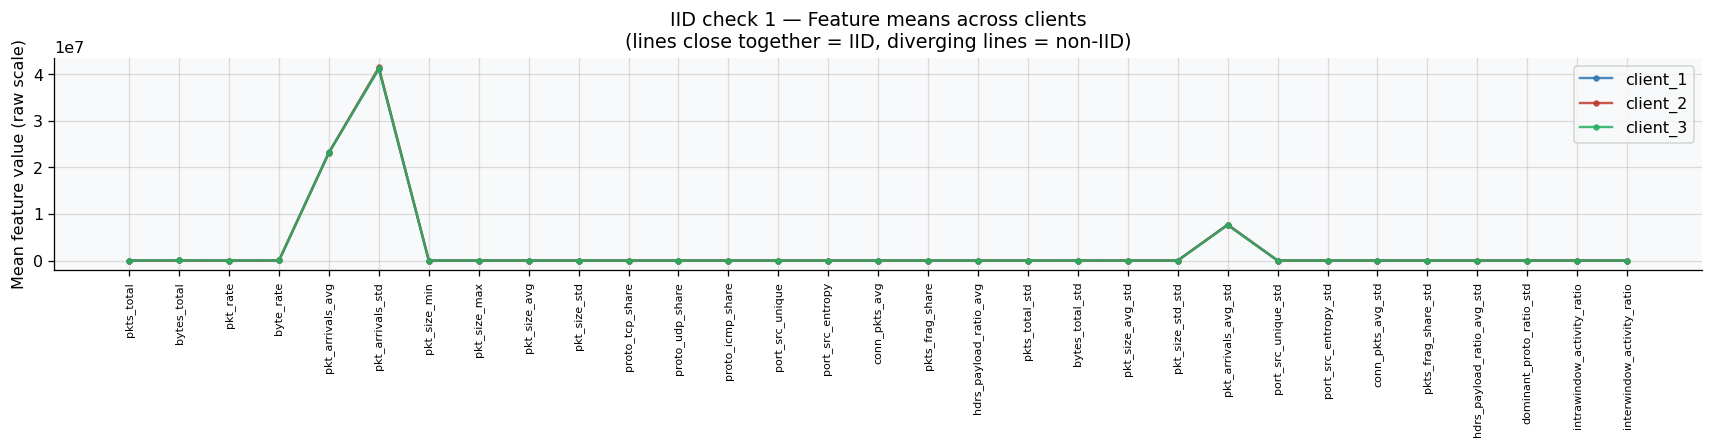

In [11]:
plt.rcParams.update({
    "figure.dpi": 115, "axes.facecolor": "#F8F9FA",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.4,
})
CLIENT_COLORS = {"client_1": "#2E75B6", "client_2": "#C0392B", "client_3": "#27AE60"}

# ── IID check 1: feature means ────────────────────────────────────────────────
# If the three clients are IID, their per-feature means should be nearly identical.
# Large divergences here indicate that certain traffic types are over-represented
# in one client relative to the others.

fig, ax = plt.subplots(figsize=(15, 4))
x = np.arange(len(FEATURE_COLS))
for cname, cdf in client_dfs.items():
    means = cdf[FEATURE_COLS].mean()
    ax.plot(x, means.values, "o-", ms=3, lw=1.5, alpha=0.85,
            color=CLIENT_COLORS[cname], label=cname)

ax.set_xticks(x)
ax.set_xticklabels(FEATURE_COLS, rotation=90, fontsize=7)
ax.set_ylabel("Mean feature value (raw scale)")
ax.set_title("IID check 1 — Feature means across clients\n"
             "(lines close together = IID, diverging lines = non-IID)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nb1_iid_means.png"), bbox_inches="tight")
plt.show()


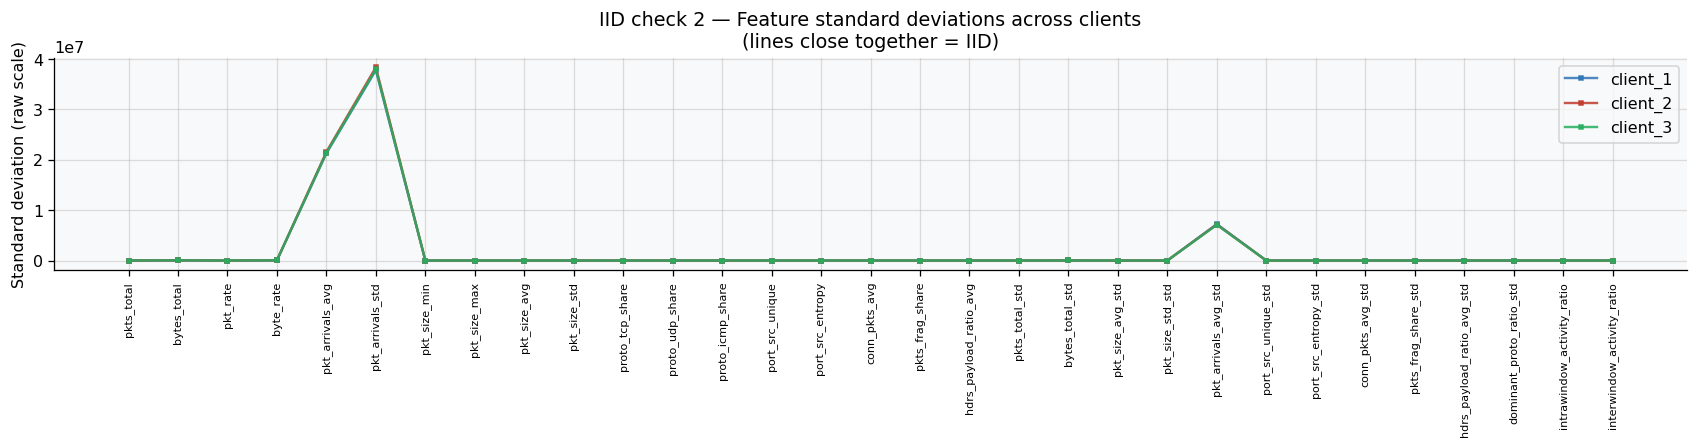

In [12]:
# ── IID check 2: feature standard deviations ─────────────────────────────────
# Similar std across clients means the spread of values is consistent.
# Very different std values indicate one client has unusually homogeneous or
# unusually variable traffic for certain features — a sign of non-IID data.

fig, ax = plt.subplots(figsize=(15, 4))
for cname, cdf in client_dfs.items():
    stds = cdf[FEATURE_COLS].std()
    ax.plot(x, stds.values, "s-", ms=3, lw=1.5, alpha=0.85,
            color=CLIENT_COLORS[cname], label=cname)

ax.set_xticks(x)
ax.set_xticklabels(FEATURE_COLS, rotation=90, fontsize=7)
ax.set_ylabel("Standard deviation (raw scale)")
ax.set_title("IID check 2 — Feature standard deviations across clients\n"
             "(lines close together = IID)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nb1_iid_stds.png"), bbox_inches="tight")
plt.show()


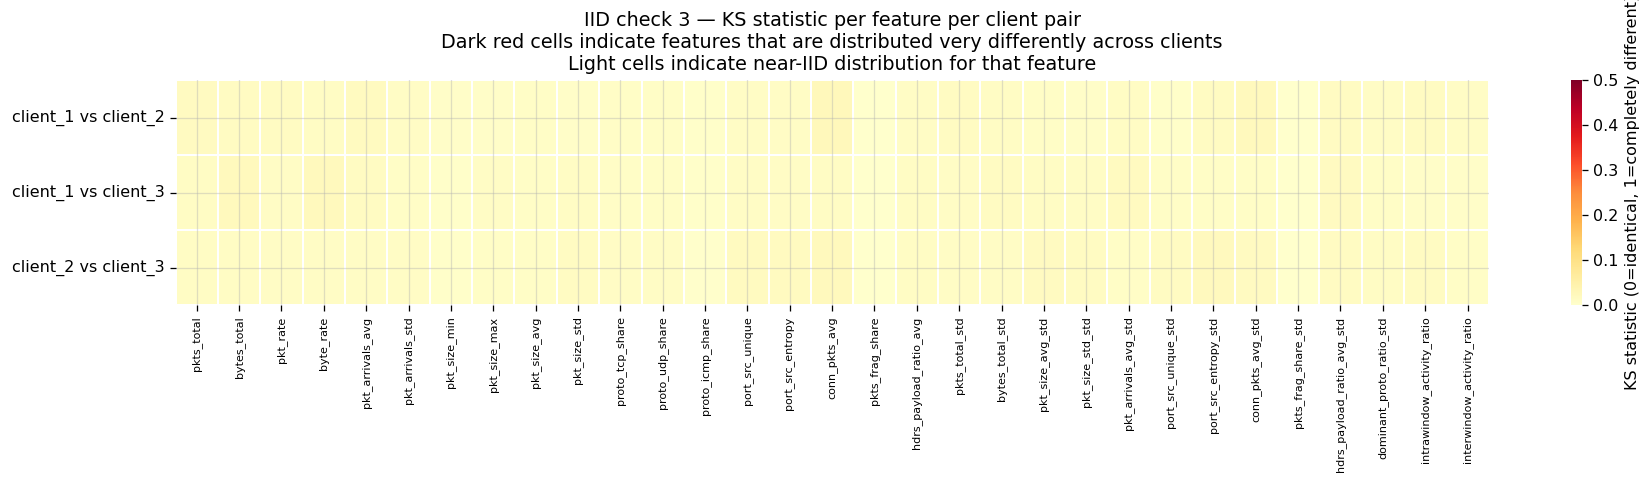


Summary — maximum KS statistic per client pair (across all features):
(Values close to 0 = IID, values above 0.2 = meaningful non-IID)
  client_1 vs client_2          max KS=0.024  (worst feature: conn_pkts_avg)  -> close to IID
  client_1 vs client_3          max KS=0.022  (worst feature: byte_rate)  -> close to IID
  client_2 vs client_3          max KS=0.022  (worst feature: conn_pkts_avg)  -> close to IID


In [13]:
# ── IID check 3: Kolmogorov-Smirnov test across client pairs ─────────────────
# The KS test compares the full empirical distribution of a feature between
# two clients, not just their mean or std. A high KS statistic (close to 1)
# means the two distributions look very different. A low statistic (close to 0)
# means they are nearly identical.
#
# We test every pair of clients for every feature and produce a heatmap showing
# the maximum KS statistic across all features for each client pair.
# "for the most divergent feature, how different do the two
# clients look?" If that maximum is low (< 0.1), the split is very close to IID.
# If it is high (> 0.3), there is meaningful heterogeneity — non-IID conditions.

from scipy.stats import ks_2samp
from itertools   import combinations

# Compute KS statistic for every (feature, client-pair) combination
client_names = list(client_dfs.keys())
pairs = list(combinations(client_names, 2))

ks_matrix = pd.DataFrame(index=[f"{a} vs {b}" for a, b in pairs],
                          columns=FEATURE_COLS, dtype=float)

for feat in FEATURE_COLS:
    for a, b in pairs:
        stat, _ = ks_2samp(
            client_dfs[a][feat].dropna().values,
            client_dfs[b][feat].dropna().values
        )
        ks_matrix.loc[f"{a} vs {b}", feat] = stat

# Plot the heatmap
fig, ax = plt.subplots(figsize=(16, 2.5 + 0.6 * len(pairs)))
import seaborn as sns
sns.heatmap(
    ks_matrix.astype(float),
    ax=ax,
    cmap="YlOrRd",
    vmin=0, vmax=0.5,
    annot=False,
    xticklabels=FEATURE_COLS,
    yticklabels=ks_matrix.index,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "KS statistic (0=identical, 1=completely different)"},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_title(
    "IID check 3 — KS statistic per feature per client pair\n"
    "Dark red cells indicate features that are distributed very differently across clients\n"
    "Light cells indicate near-IID distribution for that feature"
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nb1_iid_ks_heatmap.png"), bbox_inches="tight")
plt.show()

# Summarise: what is the maximum KS statistic across all features for each pair?
print("\nSummary — maximum KS statistic per client pair (across all features):")
print("(Values close to 0 = IID, values above 0.2 = meaningful non-IID)")
for pair_name in ks_matrix.index:
    row_max  = ks_matrix.loc[pair_name].astype(float).max()
    worst_ft = ks_matrix.loc[pair_name].astype(float).idxmax()
    verdict  = "close to IID" if row_max < 0.1 else                "mild non-IID" if row_max < 0.25 else                "strong non-IID"
    print(f"  {pair_name:<28}  max KS={row_max:.3f}  "
          f"(worst feature: {worst_ft})  -> {verdict}")


Most divergent feature: conn_pkts_avg (mean KS = 0.019)
Most uniform feature  : pkts_frag_share (mean KS = 0.000)


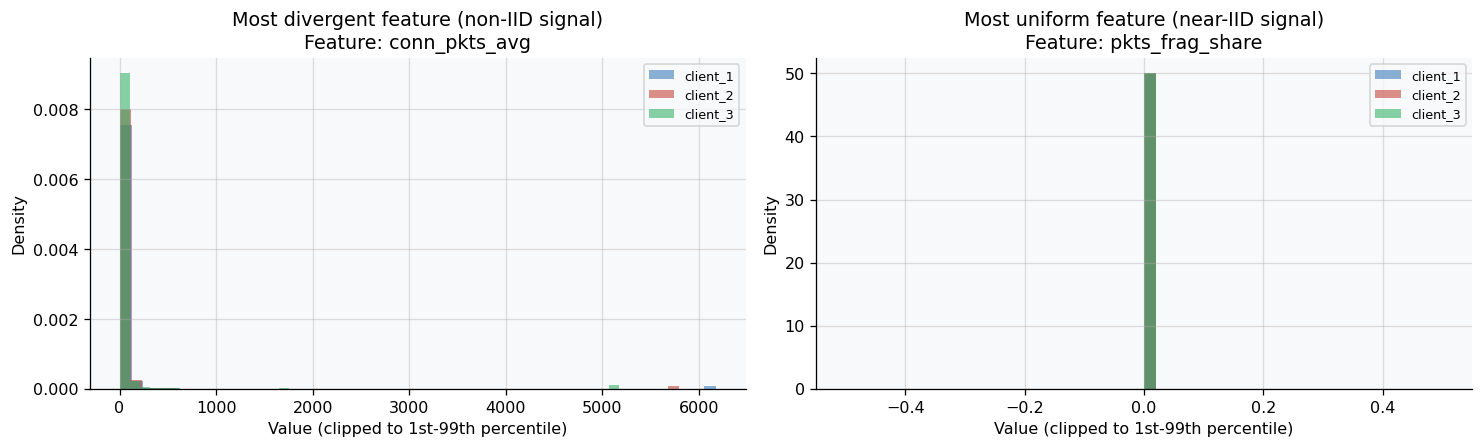

In [14]:
# ── IID check 4: distribution overlay for the most divergent feature ──────────
# Find the single feature with the highest mean KS statistic across all pairs.
# Plot the distribution of that feature across all three clients to visualise
# the nature of the divergence.

mean_ks_per_feat = ks_matrix.astype(float).mean(axis=0)
most_divergent   = mean_ks_per_feat.idxmax()
print(f"Most divergent feature: {most_divergent} "
      f"(mean KS = {mean_ks_per_feat[most_divergent]:.3f})")

# Also find the least divergent feature
least_divergent = mean_ks_per_feat.idxmin()
print(f"Most uniform feature  : {least_divergent} "
      f"(mean KS = {mean_ks_per_feat[least_divergent]:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, feat, title in zip(
    axes,
    [most_divergent, least_divergent],
    ["Most divergent feature (non-IID signal)",
     "Most uniform feature (near-IID signal)"]
):
    for cname, cdf in client_dfs.items():
        vals = cdf[feat].dropna()
        lo   = vals.quantile(0.01)
        hi   = vals.quantile(0.99)
        ax.hist(vals.clip(lo, hi), bins=50, density=True,
                alpha=0.55, label=cname,
                color=CLIENT_COLORS[cname])
    ax.set_title(f"{title}\nFeature: {feat}")
    ax.set_xlabel("Value (clipped to 1st-99th percentile)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nb1_iid_distributions.png"), bbox_inches="tight")
plt.show()


In [16]:
files_saved = (
    [f"client_{i}_train.csv" for i in range(1, N_CLIENTS+1)] +
    ["pooled_train.csv"]
)
for fname in files_saved:
    path = os.path.join(OUTPUT_DIR, fname)
    n    = len(pd.read_csv(path)) if os.path.exists(path) else 0
    print(f"  {fname:<30} {n:>8,} rows")


  client_1_train.csv                6,366 rows
  client_2_train.csv                6,366 rows
  client_3_train.csv                6,368 rows
  pooled_train.csv                 19,100 rows
